In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import tqdm

# Анализ детерминированной задачи

In [ ]:
def find_jacobian(
    func: callable,
    t: float,
    state: np.ndarray,
    params: dict,
    eps: float = 1e-6,
) -> np.ndarray:
    n = len(state)
    jacobian = np.zeros((n, n))

    for i in range(n):
        perturb = np.zeros(n)
        perturb[i] = eps
        
        f1 = func(t, state + perturb, **params)
        f2 = func(t, state - perturb, **params)
        jacobian[:, i] = (f1 - f2) / (2 * eps)
    
    return jacobian

def find_equilibrium(
    func: callable,
    guess: np.ndarray,
    params: dict,
) -> np.ndarray:    
    def root_fn(state):
        return func(0, state, **params)
    
    solution, info, ier, _ = sp.optimize.fsolve(root_fn, guess, full_output=True)
    
    if ier == 1:
        return solution
    return None


def classify_equilibrium(
    eigenvalues: np.ndarray,
    eps: float = 1e-6
) -> str:
    real = np.real(eigenvalues)
    imag = np.imag(eigenvalues)

    if np.any(real > eps) and np.any(real < -eps):
        return 'saddle'

    if np.all(np.abs(real) < eps):
        if np.any(np.abs(imag) > eps):
            return 'center'
        else:
            return 'degenerate'

    if np.any(np.abs(imag) > eps):
        if np.all(real < 0):
            return 'stable focus'
        elif np.all(real > 0):
            return 'unstable focus'

    if np.all(real < 0):
        return 'stable node'
    elif np.all(real > 0):
        return 'unstable node'

    return 'unknown'


class DynamicSystem2D:

    def __init__(
        self,
        model_func: callable,
        params: dict = None,
    ):
        """
        Args:
            model_func: function returning a vector of (dx/dt, dy/dt)
            params: dictionary of parameters
        """
        self.model_func = model_func
        self.params = params if params is not None else {}

    def solve(
        self,
        state_init: np.ndarray,
        time_span: np.ndarray
    ) -> np.ndarray:
        """
        Find numeric solution for the system using 4-th order Runge-Kutta method.
        
        Args:
            state_init: initial state (x_0, y_0) of the dynamic system
            time_span: uniform time grid
        
        Returns:
            solution: array system states per time point throughout the time span
        """
        n = len(time_span)
        h = time_span[1] - time_span[0]
        
        solution = np.zeros((n, len(state_init)))
        solution[0] = state_init.copy()

        for i in range(n - 1):
            t = time_span[i]
            state_curr = solution[i]
            
            k1 = h * self.model_func(t, state_curr, **self.params)
            k2 = h * self.model_func(t + h/2, state_curr + k1/2, **self.params)
            k3 = h * self.model_func(t + h/2, state_curr + k2/2, **self.params)
            k4 = h * self.model_func(t + h, state_curr + k3, **self.params)
            
            solution[i + 1] = state_curr + (k1 + 2 * k2 + 2 * k3 + k4) / 6
            
        return solution

    def plot_bifurcation_diagram(
        self,
        param_name: str,
        param_values: np.ndarray,
        state_init: np.ndarray,
        ax: plt.Axes,
    ):
        """
        Plot bifurcation diagram for a dynamic system.

        Iterate over the dense grid of parameter values, and detect eigenvalue sign changes
        for Jacobians of equilibrium states, marking them as bifurcation points.

        Real part of the eigenvalues of the Jacobian indicates the system stability/instability
        per parameter value (<0 ==> stable, >0 ==> unstable).
        """
        equilibria = []
        stability_mask = []
        types = []
        param_used = []
        bifurcation_points = []

        eigenvalues_last = None

        for val in param_values:
            self.params[param_name] = val

            equilibrium = find_equilibrium(self.model_func, state_init, self.params)
            if equilibrium is None:
                continue

            jacobian = find_jacobian(self.model_func, 0, equilibrium, self.params)
            eigenvalues = np.linalg.eigvals(jacobian)

            # equillibrium classification
            eq_type = classify_equilibrium(eigenvalues)
            types.append(eq_type)

            is_stable = np.all(np.real(eigenvalues) < 0)
            stability_mask.append(is_stable)

            # bifurcation check
            if eigenvalues_last is not None:
                if np.any(np.real(eigenvalues_last) * np.real(eigenvalues) < 0):
                    bifurcation_points.append(val)
                    ax.axvline(val, linestyle='--', label='bifurcation point')

            equilibria.append(equilibrium)
            param_used.append(val)

            eigenvalues_last = eigenvalues
            state_init = equilibrium

        equilibria = np.array(equilibria)
        stability_mask = np.array(stability_mask)
        param_used = np.array(param_used)

        x_eq = equilibria[:, 0]

        type_to_color = {
            'stable node': 'blue',
            'unstable node': 'red',
            'saddle': 'black',
            'stable focus': 'green',
            'unstable focus': 'orange',
            'center': 'purple',
            'degenerate': 'gray',
        }

        for t in set(types):
            mask = np.array([tt == t for tt in types])
            ax.scatter(
                param_used[mask],
                x_eq[mask],
                label=t,
                color=type_to_color.get(t, 'gray'),
                s=20,
            )

        ax.set_xlabel(param_name)
        ax.set_ylabel('x')
        ax.set_title('Bifurcation diagram (with equilibrium types)')
        ax.legend()
        ax.grid(True)

        return bifurcation_points
    
    def plot_trajectory(
        self,
        state_init: np.ndarray,
        time_span: np.ndarray,
        ax: plt.Axes,
        label: str,
    ) -> None:
        """
        Plot trajectory for given initial state.
        """
        solution = self.solve(state_init, time_span)
        ax.plot(solution[:, 0], solution[:, 1], label=label)
        ax.set_title('Phase portrait')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.legend(loc='upper right')
        ax.grid(True)
    
    def plot_phase_portrait_dense(
        self,
        ax: plt.Axes,
        time_span: np.ndarray,
        bounds: tuple = (-2, 2),
        grid_size: int = 10,
    ):
        """
        Plot phase portrait based on a grid of initial states.
        """
        xmin, xmax = bounds
        ymin, ymax = bounds

        # initialize grid
        x_vals = np.linspace(xmin, xmax, grid_size)
        y_vals = np.linspace(ymin, ymax, grid_size)

        # test trajectories for all initial states on the grid
        for x0 in x_vals:
            for y0 in y_vals:
                state_init = np.array([x0, y0])

                solution = self.solve(state_init, time_span)
                if np.all(np.isfinite(solution)):
                    ax.plot(solution[:, 0], solution[:, 1], color='blue', alpha=0.5)

        # plot vector field
        X, Y = np.meshgrid(
            np.linspace(xmin, xmax, 25),
            np.linspace(ymin, ymax, 25)
        )

        U = np.zeros_like(X)
        V = np.zeros_like(Y)

        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                dx, dy = self.model_func(
                    0,
                    np.array([X[i, j], Y[i, j]]),
                    **self.params
                )
                U[i, j] = dx
                V[i, j] = dy

        # normalize vector field
        norm = np.sqrt(U**2 + V**2)
        U /= (norm + 1e-8)
        V /= (norm + 1e-8)

        ax.streamplot(X, Y, U, V, density=1.2, color='black', linewidth=0.5)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True)

# 1. Нейронная модель ФитцХью -- Нагумо (FHN)
$$
\begin{cases}
    \dot{x} = \frac{1}{\delta} (x - \frac{x^3}{3} - y) \\
    \dot{y} = x + a
\end{cases}
$$

1. Найдем равновесия системы.
$$
\begin{cases}
    \frac{1}{\delta} (x - \frac{x^3}{3} - y) = 0 \\
    x + a = 0
\end{cases}

\Rightarrow

\begin{cases}
    \overline{x} = -a \\
    \overline{y} = \frac{a^3}{3} - a
\end{cases}
$$

2. Исследуем равновесия на устойчивость.
$$
J(x, y) = \begin{pmatrix}
\frac{1}{\delta} (1 - x^2) & \frac{1}{\delta} \\
1 & 0
\end{pmatrix} \\

\Downarrow \\

|J(x, y) - \lambda E| = 0 \\

\Downarrow \\

\lambda_{1,2}(x, y) = \frac{-\delta x^2 + \delta \pm \delta \sqrt{x^4 - 2 x^2 - 4 \delta + 1}}{2 \delta^2}
$$

С помощью численной процедуры исследуем поведение собственных чисел якобиана при различных значениях параметра $a$ (далее).

In [3]:
def model_FHN(
    time: float,
    state: np.ndarray,
    delta: float = 0.1,
    a: float = 1,
):
    """
    FitzHugh-Nagumo neural model.
    Accepts `time` argument for interface consistency, but does not use it.
    
    Parameter restrictions:
    - delta << 1 (delta = 0.1)
    - a > 0
    """
    x, y = state
    return np.array([
        (x - (x ** 3) / 3 - y) / delta,
        x + a
    ])

In [4]:
FHN = DynamicSystem2D(
    model_FHN,
    params=dict(delta=0.1, a=1)
)

state_init = np.array([0, 0])
time_span = np.linspace(0, 50, num=2000)
param_values = np.linspace(0, 2, num=50)

3. Построим бифуркационную диаграмму по параметру $a$.

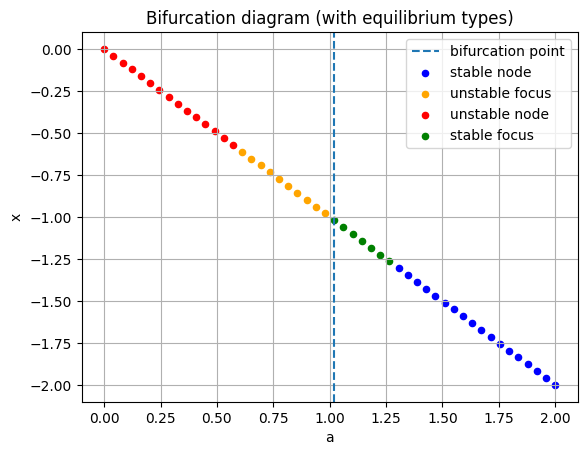

In [5]:
fig, ax = plt.subplots()

bifurcation_points = FHN.plot_bifurcation_diagram(
    param_name='a',
    param_values=param_values,
    state_init=state_init,
    ax=ax
)

a_bif = bifurcation_points[0]

4. Построим типичные фазовые портреты для различных значений $a$ на бифуркационной диаграмме.

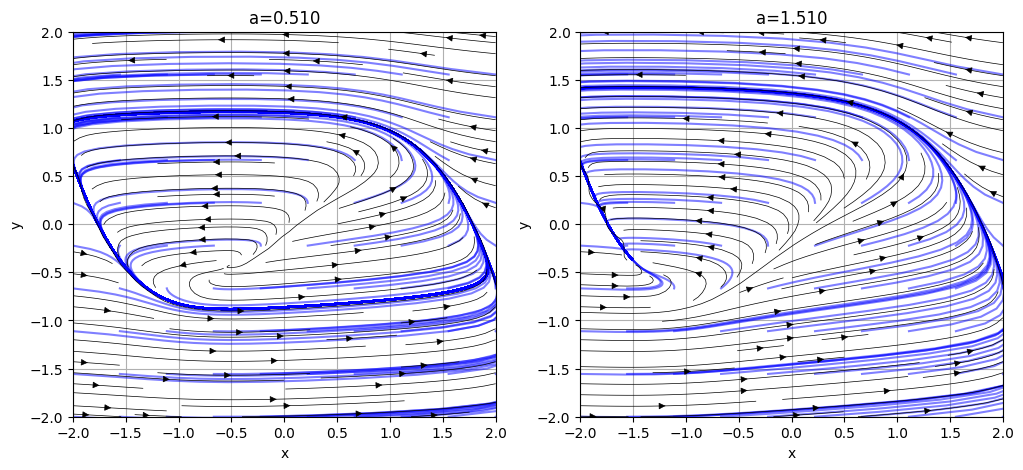

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

a_min = param_values[0]
a_max = param_values[-1]

a_left  = (a_min + a_bif) / 2
a_right = (a_bif + a_max) / 2

for ax, a in zip(axes, [a_left, a_right]):
    FHN.params['a'] = a

    FHN.plot_phase_portrait_dense(
        ax=ax,
        time_span=time_span,
        bounds=(-2, 2),
        grid_size=10
    )

    ax.set_title(f"{a=:.3f}")

# 2. Климатическая модель Зальцман-Николис (SN)
$$
\begin{cases}
    \dot{x} = y - x \\
    \dot{y} = -a x + b y - x^2 y
\end{cases}
$$

1. Найдем равновесия системы.
$$
\begin{cases}
    y - x = 0 \\
    -a x + b y - x^2 y = 0
\end{cases}

\Rightarrow

\begin{cases}
    x = y \\
    x(x^2 + a - b) = 0
\end{cases}

\Rightarrow

\begin{cases}
    (\overline{x}_1, \overline{y}_1) = (0, 0) \\
    (\overline{x}_2, \overline{y}_2) = (\sqrt{b - a}, \sqrt{b - a}) \\
    (\overline{x}_3, \overline{y}_3) = (-\sqrt{b - a}, -\sqrt{b - a})
\end{cases}
$$

2. Исследуем равновесия на устойчивость.
$$
J(x, y) = \begin{pmatrix}
-1 & 1 \\
-a - 2xy & b - x^2
\end{pmatrix} \\

\Downarrow \\

|J(x, y) - \lambda E| = 0 \\

\Downarrow \\

\lambda_{1,2}(x, y) = \frac{\pm \sqrt{-4a + b^2 - 2b x^2 + 2b + x^4 - 2x^2 - 8xy + 1} + b - x^2 - 1}{2}
$$

С помощью численной процедуры исследуем поведение собственных чисел якобиана при различных значениях параметра $a$ (далее).

In [7]:
def model_SN(
    time: float,
    state: np.ndarray,
    a: float = 1,
    b: float = 2,
):
    """
    Saltzman-Nicolis climate model.
    Accepts `time` argument for interface consistency, but does not use it.
    
    Parameter restrictions:
    - a > 0
    - b = 2
    """
    x, y = state
    return np.array([
        y - x,
        -a * x + b * y - (x ** 2) * y
    ])

In [13]:
SN = DynamicSystem2D(
    model_SN,
    params=dict(a=1, b=2)
)

state_init = np.array([0.1, 0.1])
time_span = np.linspace(0, 50, num=2000)
param_values = np.linspace(0, 3, num=50)

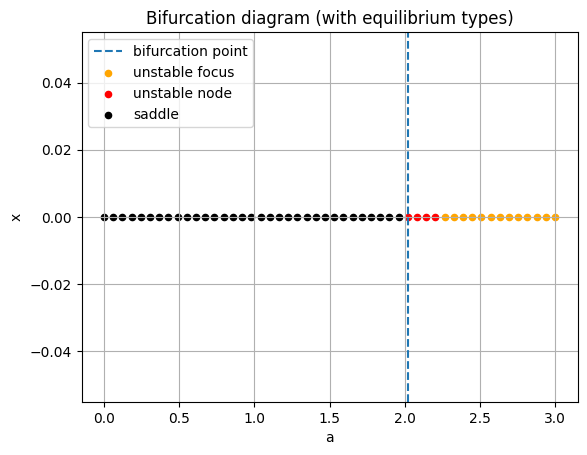

In [14]:
fig, ax = plt.subplots()

bifurcation_points = SN.plot_bifurcation_diagram(
    param_name='a',
    param_values=param_values,
    state_init=state_init,
    ax=ax
)

a_bif = bifurcation_points[0]

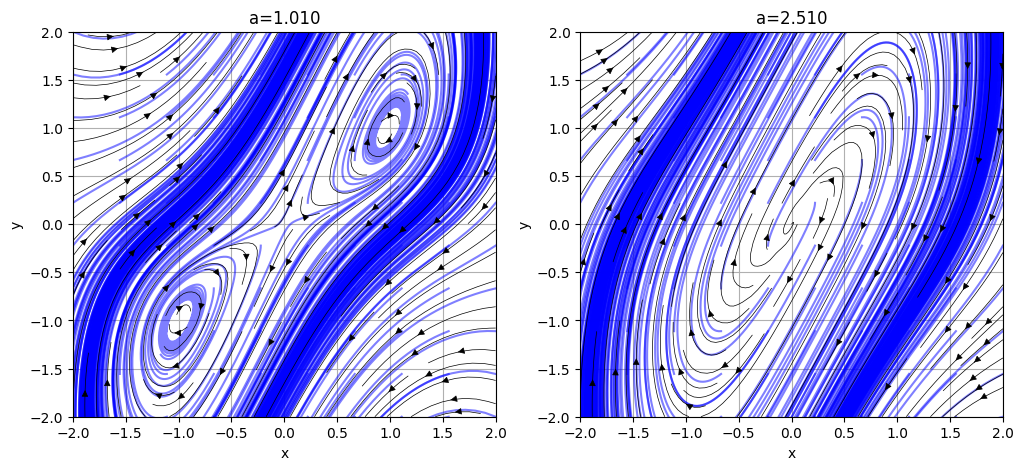

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

a_min = param_values[0]
a_max = param_values[-1]

a_left  = (a_min + a_bif) / 2
a_right = (a_bif + a_max) / 2

for ax, a in zip(axes, [a_left, a_right]):
    SN.params['a'] = a

    SN.plot_phase_portrait_dense(
        ax=ax,
        time_span=time_span,
        bounds=(-2, 2),
        grid_size=10
    )

    ax.set_title(f"{a=:.3f}")